In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.column()

AttributeError: 'DataFrame' object has no attribute 'column'

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [10]:
df.dropna(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Churn"]

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7032, dtype: str

In [13]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [ ]:
KPI 1 — Churn Rate
Churn Rate=TCustomers Who Left/ otal Customers ×100

In [14]:
churn_rate = (df['Churn'].value_counts()['Yes'] / len(df)) * 100

print("Churn Rate:", churn_rate)

Churn Rate: 26.578498293515356


In [ ]:
KPI 2 — Retention Rate

Retention Rate=100−Churn Rate

In [15]:
retention_rate = 100 - churn_rate

print("Retention Rate:", retention_rate)

Retention Rate: 73.42150170648465


In [ ]:
KPI 3 — Average Monthly Charges
Average Monthly Charges=Total Monthly Charges/Number of Customers


In [16]:
avg_monthly = df["MonthlyCharges"].mean()

print(avg_monthly)

64.79820819112628


In [ ]:
KPI 4 — Revenue Lost Due to Churn

In [17]:
revenue_loss = df[df["Churn"]=="Yes"]["MonthlyCharges"].sum()

print(revenue_loss)

139130.85


In [ ]:
Exploratory Data Analysis (EDA)
A. Churn Distribution

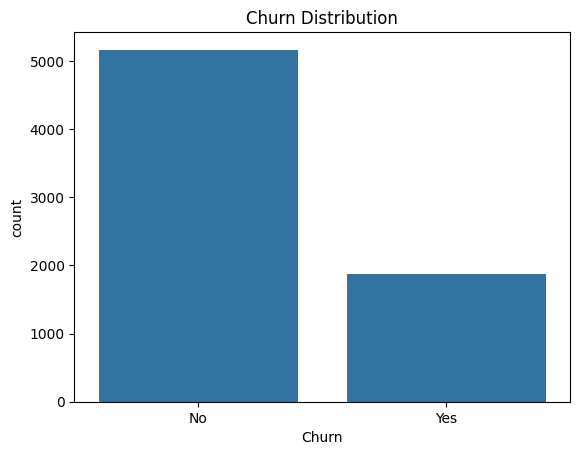

In [18]:
sns.countplot(x='Churn', data=df)

plt.title("Churn Distribution")

plt.show()

In [ ]:
INSIGHT : The company experiences a significant number of customer exits, indicating retention issues.

In [ ]:
B. Contract Type vs Churn

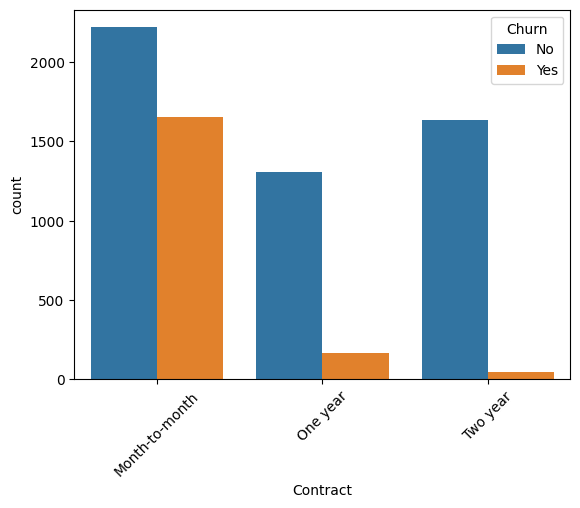

In [19]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.xticks(rotation=45)

plt.show()

In [ ]:
Insight :

Customers with month-to-month contracts churn more frequently than long-term contract users.

In [ ]:
C. Monthly Charges vs Churn

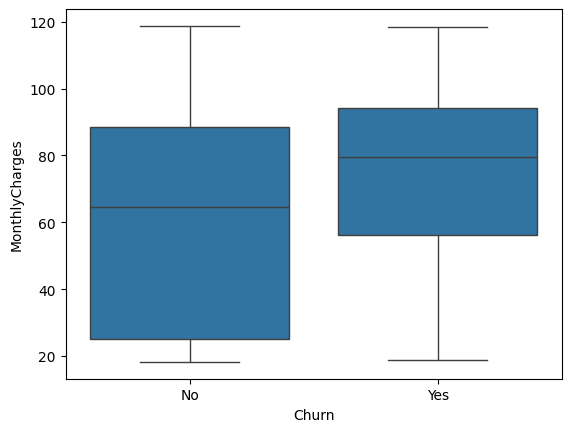

In [20]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.show()

In [ ]:
Insight :

Customers with higher monthly charges are more likely to churn.

In [ ]:
D. Tenure vs Churn

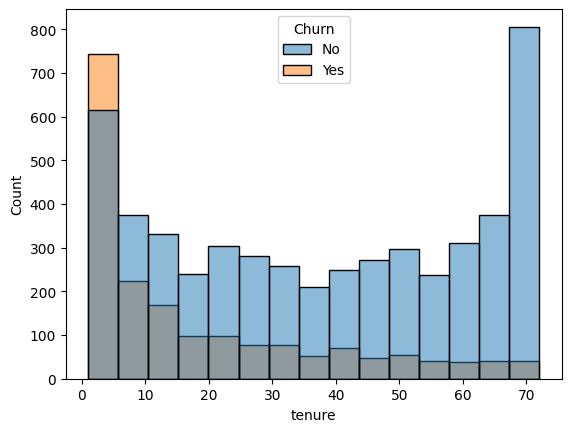

In [21]:
sns.histplot(data=df, x='tenure', hue='Churn')

plt.show()

In [ ]:
Insight:

New customers are more likely to leave early compared to long-term customers.

In [ ]:
Deep-Dive Analysis

In [ ]:
Question 1
Which contract type has highest churn?

In [22]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [ ]:
Question 2
Which payment method causes highest churn?

In [23]:
pd.crosstab(df['PaymentMethod'], df['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


In [ ]:
Question 3
Which internet users churn most?

In [24]:
pd.crosstab(df['InternetService'], df['Churn'])

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [ ]:
SEGMENTATION ANALYSIS

In [25]:
def customer_segment(tenure):
    
    if tenure <= 12:
        return "New Customer"
    
    elif tenure <= 36:
        return "Regular Customer"
    
    else:
        return "Loyal Customer"

df['CustomerSegment'] = df['tenure'].apply(customer_segment)

In [26]:
df['CustomerSegment'].value_counts()

CustomerSegment
Loyal Customer      3001
New Customer        2175
Regular Customer    1856
Name: count, dtype: int64

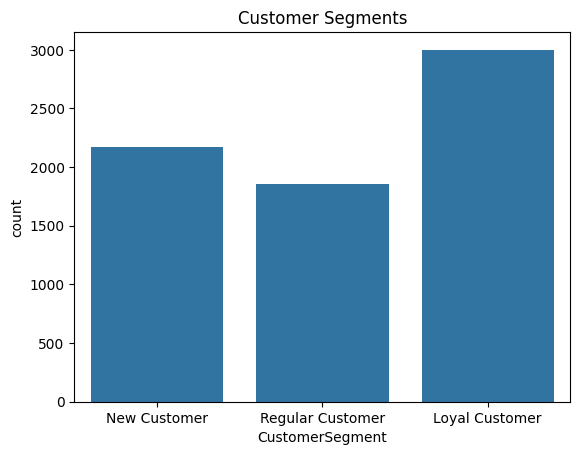

In [27]:
sns.countplot(x='CustomerSegment', data=df)

plt.title("Customer Segments")

plt.show()

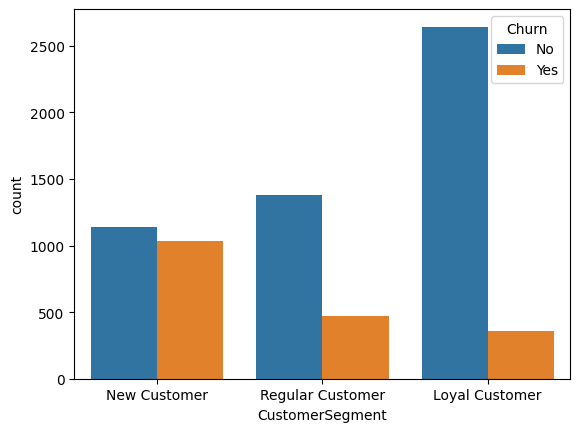

In [28]:
sns.countplot(x='CustomerSegment', hue='Churn', data=df)

plt.show()

In [29]:
def spending_segment(charge):

    if charge < 35:
        return "Budget"

    elif charge < 70:
        return "Standard"

    else:
        return "Premium"

df['SpendingSegment'] = df['MonthlyCharges'].apply(spending_segment)

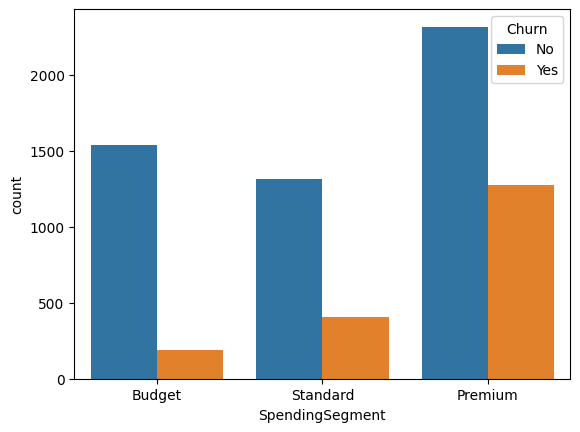

In [30]:
sns.countplot(x='SpendingSegment', hue='Churn', data=df)

plt.show()

In [31]:
df.to_csv("final_churn_dataset.csv", index=False)